In [1]:
import pandas as pd


In [2]:
data=pd.read_csv(r"E:\Data\housing.csv")

In [3]:
data


,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0.0,0.538,6.575,65.2,4.0900,1,296.0,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0.0,0.469,6.421,78.9,4.9671,2,242.0,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0.0,0.469,7.185,61.1,4.9671,2,242.0,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0.0,0.458,6.998,45.8,6.0622,3,222.0,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0.0,0.458,7.147,54.2,6.0622,3,222.0,18.7,396.90,5.33,36.2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
501,0.06263,0.0,11.93,0.0,0.573,6.593,69.1,2.4786,1,273.0,21.0,391.99,9.67,22.4
502,0.04527,0.0,11.93,0.0,0.573,6.120,76.7,2.2875,1,273.0,21.0,396.90,9.08,20.6
503,0.06076,0.0,11.93,0.0,0.573,6.976,91.0,2.1675,1,273.0,21.0,396.90,5.64,23.9
504,0.10959,0.0,11.93,0.0,0.573,6.794,89.3,2.3889,1,273.0,21.0,393.45,6.48,22.0


In [4]:
from sklearn.linear_model import LinearRegression

In [5]:
model=LinearRegression()

In [6]:
data.isna().sum()

CRIM        0
ZN          0
INDUS       0
CHAS        0
NOX         0
RM          0
AGE         0
DIS         0
RAD         0
TAX         0
PTRATIO     0
B           0
LSTAT       0
MEDV       54
dtype: int64

In [7]:
data=data.dropna(subset=["MEDV"])

In [8]:
x=data.drop("MEDV",axis=1)
y=data.MEDV

In [9]:
data.isna().sum()

CRIM       0
ZN         0
INDUS      0
CHAS       0
NOX        0
RM         0
AGE        0
DIS        0
RAD        0
TAX        0
PTRATIO    0
B          0
LSTAT      0
MEDV       0
dtype: int64

In [10]:
model.fit(x,y)

LinearRegression()

In [11]:
model.predict([[0.00785,16.0,12.5,1,0.555,9.654,45.6,3.0800,3,345.0,18.3,396.90,5.65]])

C:\ProgramData\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([46.92377639])

In [12]:
import warnings
warnings.filterwarnings("ignore")

In [13]:
predictions=model.predict(x)

In [14]:
from sklearn.metrics import mean_absolute_error
mae=mean_absolute_error(predictions,y)

In [15]:
mae

3.0448430251956635

In [16]:
from sklearn.metrics import mean_squared_error
mse=mean_squared_error(predictions,y)

In [17]:
mse

20.088555638541088

In [18]:
model.score(x,y)

0.7405243172971454

In [19]:
from sklearn.metrics import r2_score
r2_score(y,predictions)

0.7405243172971454

In [20]:
import seaborn as sns


In [21]:
cor=data.corr()


<Axes: >

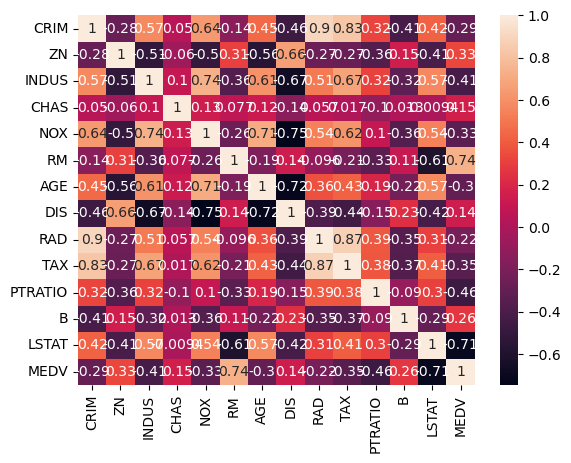

In [22]:
sns.heatmap(cor,annot=True)

In [23]:
m=model.coef_
print(m)

[-2.38024776e-01  3.82205042e-02  5.13558367e-02  2.43504780e+00
 -1.16579857e+01  5.11015834e+00 -6.09415860e-03 -1.27151396e+00
  2.94444280e-01 -1.13598117e-02 -8.31030389e-01  1.23142862e-02
 -5.20753302e-01]


In [24]:
b=model.intercept_
print(b)

20.86636535187912


In [25]:
import joblib

In [26]:
joblib.dump(model,"housing")

['housing']

In [27]:
mymodel=joblib.load("housing")

In [31]:
mymodel.predict([[0.00785,16.0,12.5,1,0.555,9.654,45.6,3.0800,3,345.0,18.3,396.90,5.65]])

array([46.92377639])

In [30]:
mymodel.score(x,y)

0.7405243172971454

In [32]:
import datetime

In [33]:
datetime.datetime.now().strftime("%Y-%m-%d-%H:%M:%S")

'2026-06-21-18:27:23'